In [1]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

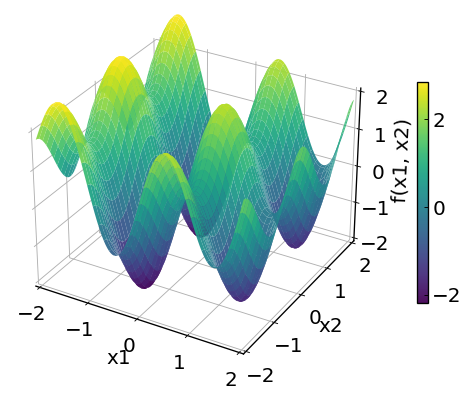

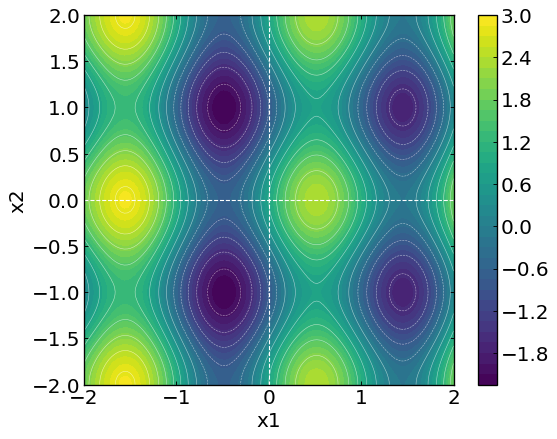

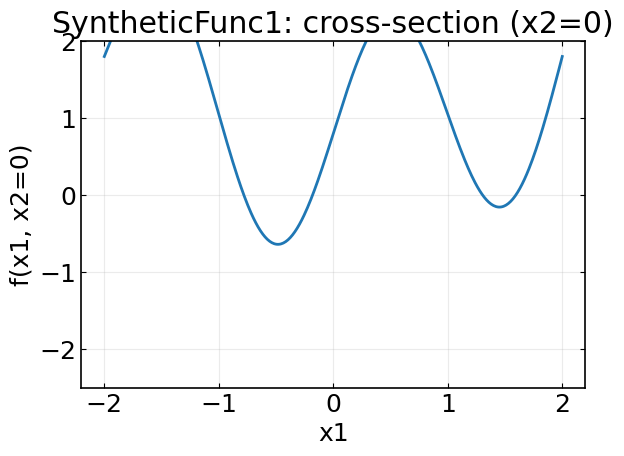

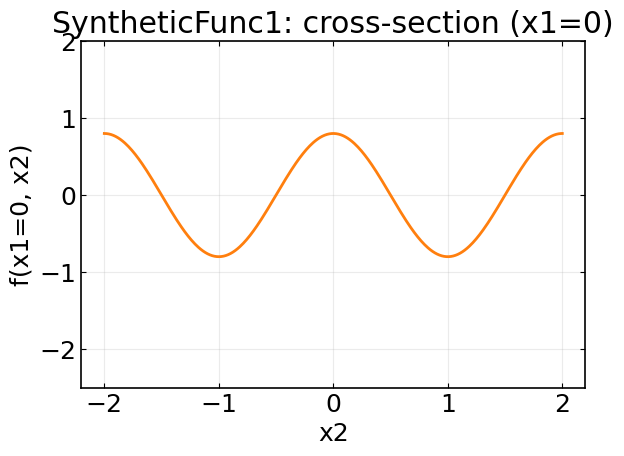

--- Strategy Selected: LCB (2D, SyntheticFunc1) ---
--- Starting Optimization Loop (25 iterations) ---
Iter  | Best y     | New y      | New x
--------------------------------------------------------------------------------
1     | -1.982333   | -1.982333   | [-0.437,  1.254]
2     | -1.982333   | -1.925865   | [-0.273,  1.039]
3     | -2.188416   | -2.188416   | [-0.556,  0.958]
4     | -2.188416   | -1.882523   | [-0.452,  0.679]
5     | -2.188416   | -1.427816   | [-0.718,  0.672]
6     | -2.188416   | -1.634414   | [-0.722,  1.217]
7     | -2.188416   | -0.994873   | [-0.601,  1.644]
8     | -2.216869   | -2.216869   | [-0.433,  0.929]
9     | -2.216869   | -2.164502   | [-0.503,  0.869]
10    | -2.233171   | -2.233171   | [-0.467,  1.049]
11    | -2.248934   | -2.248934   | [-0.474,  1.003]
12    | -2.248934   | -2.229562   | [-0.475,  1.002]
13    | -2.248934   | -2.218614   | [-0.476,  1.000]
14    | -2.248934   | -2.234111   | [-0.501,  1.028]
15    | -2.248934   | -2.245091   

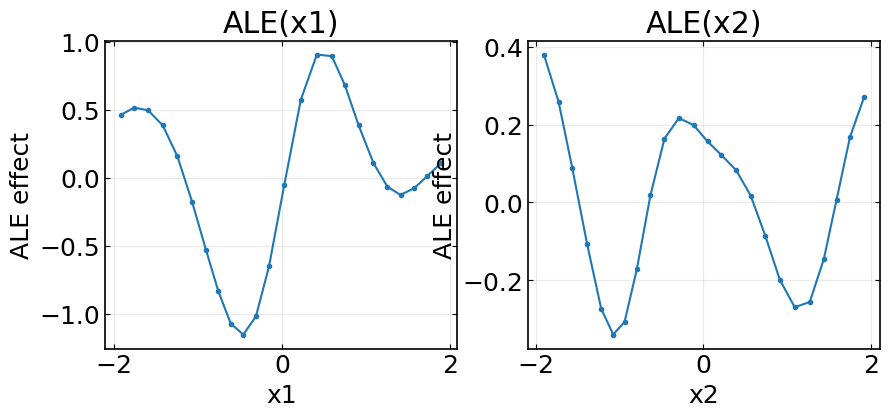

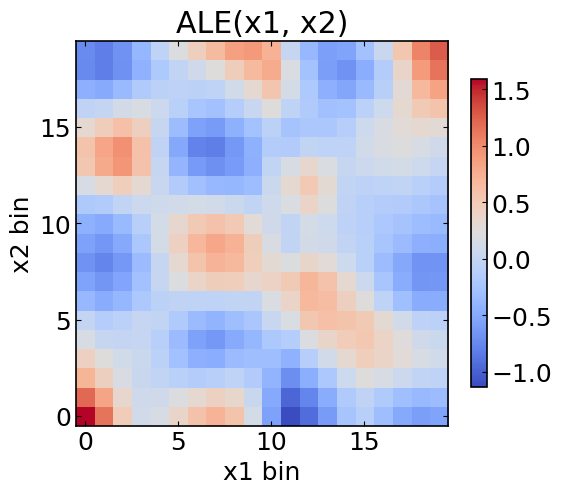

In [2]:

# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 4.0
noise_std = 0.01
noise_var = noise_std ** 2

# Domain settings (2D)
dims = 2
lower_bounds = [-2.0, -2.0]
upper_bounds = [2.0, 2.0]

# -------------------- 2.5 Synthetic Functions (ICE/PDP study) --------------------
def SyntheticFunc1(X):
    """ICE/PDPが有効な例（独立・加法的）。"""
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return 1.5 * np.sin(np.pi * x1) + 0.25 * x1**2 + 0.8 * np.cos(np.pi * x2)


def SyntheticFunc2(X):
    """ICE/PDPが有効でない例1（強い交互作用）。"""
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.sin(np.pi * x1 * x2) + 0.25 * x1


def SyntheticFunc3(X):
    """ICE/PDPが有効でない例2（相関入力を前提）。"""
    X = np.atleast_2d(X)
    x1 = X[:, 0]
    x2 = X[:, 1]
    return np.exp(-5.0 * (x1 - x2) ** 2) + 0.2 * np.sin(2.0 * np.pi * (x1 + x2))


def sample_inputs(func_name, n, rng=None):
    """関数ごとの入力分布に従って2次元入力をサンプリング。"""
    rng = np.random.default_rng() if rng is None else rng
    if func_name in ("SyntheticFunc1", "SyntheticFunc2"):
        # x1, x2 iid ~ Unif[-2, 2]
        return rng.uniform(-2.0, 2.0, size=(n, 2))
    if func_name == "SyntheticFunc3":
        # x1 ~ Unif[-2,2], eta ~ N(0, 0.1^2), x2 = x1 + eta
        x1 = rng.uniform(-2.0, 2.0, size=n)
        eta = rng.normal(0.0, 0.1, size=n)
        x2 = x1 + eta
        return np.column_stack([x1, x2])
    raise ValueError(f"Unknown function name: {func_name}")


# 使用する関数を選択（"SyntheticFunc1" / "SyntheticFunc2" / "SyntheticFunc3"）
target_func_name = "SyntheticFunc1"
target_func = {"SyntheticFunc1": SyntheticFunc1, "SyntheticFunc2": SyntheticFunc2, "SyntheticFunc3": SyntheticFunc3}[target_func_name]



# -------------------- 2.6 Selected function visualization (x1-x2) --------------------
plot_grid_n = 120
x1_plot = np.linspace(lower_bounds[0], upper_bounds[0], plot_grid_n)
x2_plot = np.linspace(lower_bounds[1], upper_bounds[1], plot_grid_n)
X1_plot, X2_plot = np.meshgrid(x1_plot, x2_plot)
X_plot = np.column_stack([X1_plot.ravel(), X2_plot.ravel()])
Y_plot = target_func(X_plot).reshape(X1_plot.shape)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=80, subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X1_plot, X2_plot, Y_plot, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
ax.set_ylim(-2, 2)
ax.set_xlim(-2, 2)
ax.set_zlim(-2, 2)
ax.set_facecolor('white')
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.fill = False
    axis.pane.set_edgecolor("none")
ax.grid(color='black', linestyle='--', linewidth=20,)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=80)
cont = ax.contourf(X1_plot, X2_plot, Y_plot, levels=40, cmap='viridis')
ax.contour(X1_plot, X2_plot, Y_plot, levels=12, colors='white', linewidths=0.5, alpha=0.6)
ax.axhline(0, color='white', linestyle='--', linewidth=1.0)
ax.axvline(0, color='white', linestyle='--', linewidth=1.0)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_aspect('equal', adjustable='box')
fig.colorbar(cont, ax=ax)

plt.show()

# -------------------- 2.7 Cross-sections at x1=0 / x2=0 --------------------
cross_grid_n = 400
x1_cross = np.linspace(lower_bounds[0], upper_bounds[0], cross_grid_n)
x2_cross = np.linspace(lower_bounds[1], upper_bounds[1], cross_grid_n)

y_x2eq0 = target_func(np.column_stack([x1_cross, np.zeros_like(x1_cross)]))
y_x1eq0 = target_func(np.column_stack([np.zeros_like(x2_cross), x2_cross]))

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=100)
ax.plot(x1_cross, y_x2eq0, color='tab:blue', linewidth=2.0)
ax.set_title(f'{target_func_name}: cross-section (x2=0)')
ax.set_xlabel('x1')
ax.set_ylabel('f(x1, x2=0)')
ax.grid(alpha=0.25)
ax.set_ylim(-2.5, 2)

fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=100)
ax.plot(x2_cross, y_x1eq0, color='tab:orange', linewidth=2.0)
ax.set_title(f'{target_func_name}: cross-section (x1=0)')
ax.set_xlabel('x2')
ax.set_ylabel('f(x1=0, x2)')
ax.grid(alpha=0.25)
ax.set_ylim(-2.5, 2)

plt.show()

# Optimization Loop Settings
n_init = 20
n_iter = 25

# --- Acquisition Function (LCB only) ---
acq_func = lib_debug.lower_confidence_bound
acq_params = {"kappa": 2.0}

print(f"--- Strategy Selected: LCB (2D, {target_func_name}) ---")

# -------------------- 3. Initialization --------------------
X_train = sample_inputs(target_func_name, n_init, rng=np.random.default_rng(0))
y_train = target_func(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting/analysis
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x'}")
print("-" * 80)

for i in range(n_iter):
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    x_new, _ = lib_debug.optimize_acquisition(
        kernel,
        acq_func,
        X_train,
        y_train,
        Ky_inv,
        gamma,
        lower_bounds,
        upper_bounds,
        acq_params,
    )

    y_new = target_func(x_new.reshape(1, -1)).reshape(1, 1) + np.random.normal(0, noise_std, (1, 1))

    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]: .3f}, {x_new[1]: .3f}]")

# -------------------- 5. Final fit --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

print("-" * 80)
print(f"Optimization Finished using LCB on 2D {target_func_name}.")
print(f"Global Best Found: y = {best_y.item():.6f} at x = [{best_x[0]:.4f}, {best_x[1]:.4f}]")


# -------------------- 6. ICE/PDP + ALE (main + interaction) --------------------
import matplotlib.pyplot as plt

# GP posterior mean wrapper from original lib_debug
# ALE の被説明関数 f(·) として、最終学習後の GP 予測平均を使う。
def pred_gp_debug(X):
    X = np.atleast_2d(X)
    out = np.zeros(X.shape[0])
    for i, x in enumerate(X):
        out[i] = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)[0]
    return out

# ---- ALE utilities ----
def _bin_edges_from_quantiles(x, n_bins=20):
    q = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(x, q)
    edges = np.unique(edges)
    if len(edges) < 3:
        edges = np.linspace(np.min(x), np.max(x), min(n_bins, 3))
    return edges

def ale_1d(X, pred_fn, feat_idx, n_bins=20):
    """
    1D ALE for feature j (= feat_idx).

    ユーザー想定の経験分布:
      ALE(x_j) = Σ_k [ (1/|S_k|) Σ_{i∈S_k} { f(z_k, x_{-j,i}) - f(z_{k-1}, x_{-j,i}) } ] - C

    本実装での対応:
      - S_k      : mask で抽出される bin k 内サンプル集合
      - z_{k-1},z_k : edges[k], edges[k+1]
      - (1/|S_k|)Σ : d[k] = mean(pred_fn(Xhi) - pred_fn(Xlo))
      - Σ_k(累積) : accum = cumsum(d), vals = bin 中点での累積値
      - -C       : vals = vals - Σ_k w_k vals_k （重み付き中心化）
    """
    x = X[:, feat_idx]
    edges = _bin_edges_from_quantiles(x, n_bins)
    K = len(edges) - 1

    # d[k] は bin k の局所効果平均: (1/|S_k|)Σ_i Δf_i
    d = np.zeros(K)
    cnt = np.zeros(K)
    for k in range(K):
        lo, hi = edges[k], edges[k+1]
        mask = (x >= lo) & (x < hi) if k < K-1 else (x >= lo) & (x <= hi)
        if not np.any(mask):
            d[k] = np.nan
            continue
        Xlo = X[mask].copy(); Xhi = X[mask].copy()
        Xlo[:, feat_idx] = lo; Xhi[:, feat_idx] = hi
        d[k] = np.mean(pred_fn(Xhi) - pred_fn(Xlo))
        cnt[k] = np.sum(mask)

    d = np.nan_to_num(d, nan=0.0)
    accum = np.concatenate([[0.0], np.cumsum(d)])
    vals = 0.5 * (accum[:-1] + accum[1:])

    # -C 項（経験分布上で平均 0 になるよう中心化）
    w = cnt / max(cnt.sum(), 1.0)
    vals = vals - np.sum(w * vals)

    centers = 0.5 * (edges[:-1] + edges[1:])
    return dict(edges=edges, centers=centers, effect=vals, counts=cnt)

def ale_2d_interaction(X, pred_fn, i=0, j=1, n_bins=20, empty_policy='mask', n_iter_proj=50):
    """
    2D ALE interaction A_{ij}(x_i, x_j).

    ユーザー想定の経験分布:
      ALE(x_i, x_j) = Σ_a Σ_b [ (1/|S_{ab}|) Σ_{n∈S_{ab}} D_{ab,n} ] - C

    本実装での対応:
      - S_{ab}          : m = (b1==a)&(b2==b)
      - D_{ab,n}        : f(hh)-f(hl)-f(lh)+f(ll)（2次差分）
      - (1/|S_{ab}|)Σ   : d2[a,b] = mean( ... )
      - Σ_aΣ_b(累積)    : H = cumsum(cumsum(d2))
      - -C              : weighted additive projection を除去し中心化
    """
    e1 = _bin_edges_from_quantiles(X[:, i], n_bins)
    e2 = _bin_edges_from_quantiles(X[:, j], n_bins)
    K1, K2 = len(e1)-1, len(e2)-1

    d2 = np.zeros((K1, K2)); cnt = np.zeros((K1, K2))
    b1 = np.clip(np.digitize(X[:, i], e1) - 1, 0, K1-1)
    b2 = np.clip(np.digitize(X[:, j], e2) - 1, 0, K2-1)

    for a in range(K1):
        for b in range(K2):
            m = (b1 == a) & (b2 == b)
            if not np.any(m):
                d2[a, b] = np.nan
                continue

            lo1, hi1 = e1[a], e1[a+1]
            lo2, hi2 = e2[b], e2[b+1]
            Xhh = X[m].copy(); Xhl = X[m].copy(); Xlh = X[m].copy(); Xll = X[m].copy()
            Xhh[:, i], Xhh[:, j] = hi1, hi2
            Xhl[:, i], Xhl[:, j] = hi1, lo2
            Xlh[:, i], Xlh[:, j] = lo1, hi2
            Xll[:, i], Xll[:, j] = lo1, lo2

            d2[a, b] = np.mean(pred_fn(Xhh) - pred_fn(Xhl) - pred_fn(Xlh) + pred_fn(Xll))
            cnt[a, b] = np.sum(m)

    # Σ_a Σ_b に対応する2重累積
    inc = np.nan_to_num(d2, nan=0.0)
    H = np.cumsum(np.cumsum(inc, axis=0), axis=1)

    # -C に対応: 定数 + 行効果 + 列効果を重み付きで除去
    mask = cnt > 0
    W = cnt / max(cnt.sum(), 1.0)
    A = H.copy()
    A[~mask] = np.nan

    m = np.nan_to_num(A, nan=0.0)
    r = np.zeros(K1); c = np.zeros(K2); mu = 0.0
    for _ in range(n_iter_proj):
        den = np.sum(W, axis=1) + 1e-12
        r = (np.sum(W * (m - mu - c[None, :]), axis=1)) / den
        den = np.sum(W, axis=0) + 1e-12
        c = (np.sum(W * (m - mu - r[:, None]), axis=0)) / den
        mu = np.sum(W * (m - r[:, None] - c[None, :]))

    A12 = m - mu - r[:, None] - c[None, :]
    if empty_policy == 'mask':
        A12 = np.where(mask, A12, np.nan)

    c1 = 0.5 * (e1[:-1] + e1[1:])
    c2 = 0.5 * (e2[:-1] + e2[1:])
    return dict(edges1=e1, edges2=e2, centers1=c1, centers2=c2, A12=A12, counts=cnt, mask=mask)

# ---- ALE estimation from reference empirical distribution ----
X_ref = sample_inputs(target_func_name, 2500, rng=np.random.default_rng(7))
ale1 = ale_1d(X_ref, pred_gp_debug, feat_idx=0, n_bins=24)  # ALE(x1)
ale2 = ale_1d(X_ref, pred_gp_debug, feat_idx=1, n_bins=24)  # ALE(x2)
ale12 = ale_2d_interaction(X_ref, pred_gp_debug, 0, 1, n_bins=20, empty_policy='mask')  # ALE(x1,x2)

# ---- Visualization: output only ALE(x1), ALE(x2), ALE(x1, x2) ----
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=100)
ax[0].plot(ale1['centers'], ale1['effect'], '-o', ms=3)
ax[0].set_title('ALE(x1)')
ax[0].set_xlabel('x1')
ax[0].set_ylabel('ALE effect')
ax[0].grid(alpha=0.25)

ax[1].plot(ale2['centers'], ale2['effect'], '-o', ms=3)
ax[1].set_title('ALE(x2)')
ax[1].set_xlabel('x2')
ax[1].set_ylabel('ALE effect')
ax[1].grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=100)
im = ax.imshow(ale12['A12'].T, origin='lower', aspect='auto', cmap='coolwarm')
ax.set_title('ALE(x1, x2)')
ax.set_xlabel('x1 bin')
ax.set_ylabel('x2 bin')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()
